# Where did we go wrong?? 
## Breaking down our hosting capacity calculations

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box, MultiLineString

In [2]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [3]:
# set option to see all data frame columns
pd.set_option('display.max_columns', None)

# Investigating FeederName: AIRWAYS 1103

In [4]:
# Read in circuits, and crop to a single feederline
pge_circuits = gpd.read_file("../../../../../capstone/electrigrid/data/utilities/pge_shapefiles/LineDetail/LineDetail.shp").to_crs("EPSG:4326")

airway = pge_circuits[pge_circuits['FeederName'] == "AIRWAYS 1103"]

### Convert all MW columns to KW

In [5]:
vars = ['GenCapacit', 'GenericPVC', 'GenCapac_1', 'GenericCap', 'LoadCapaci']

for col in vars:
    pge_circuits[col] = pge_circuits[col] / 1000

In [6]:
pge_circuits.head(2)

,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
0,062541102,MERIDIAN 1102,{3F991049-BA44-489F-A403-DA79E95B5F6A},3862041,0.00,12.0,3,None,None,May 2024,May 2024,Sacramento,0.00,0.00,0.00,0.00,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,145.642120,"LINESTRING (-121.95921 39.12370, -121.95951 39..."
1,043302102,MONROE 2102,{65E86C65-2474-4DE9-831A-73C5C6C88469},5458148,2.38,21.0,3,None,None,Feb 2025,Feb 2025,Sonoma,0.06,0.07,2.44,2.44,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.102052,"LINESTRING (-122.73809 38.48070, -122.73809 38..."


### Remove unecessary rows

In [7]:
airway = airway[['FeederId', 'LoadCapaci', 'GenCapacit', 'GenericPVC', 'GenCapac_1', 'GenericCap', 'geometry']]
airway.head(2)

,FeederId,LoadCapaci,GenCapacit,GenericPVC,GenCapac_1,GenericCap,geometry
4320,252041103,0,0,0,0,0,"LINESTRING (-119.68330 36.77218, -119.68324 36..."
7817,252041103,0,0,0,0,0,"LINESTRING (-119.68609 36.78440, -119.68609 36..."


In [8]:
airway['GenCapacit'].describe()

count    282.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: GenCapacit, dtype: float64

In [9]:
airway['LoadCapaci'].describe()

count    282.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: LoadCapaci, dtype: float64

## Conclusion: the selected feederline didn't have any data, explaining why we had null results :)

# Investigating feederlines where values = 0

In [10]:
nrow = pge_circuits.count().iloc[1]
nrow_feeders = pge_circuits.groupby('FeederId').count().shape[0]

In [11]:
nrow_feeders

2928

### Generation capacity

In [12]:
# how many observations have generation capacity = to 0?
gencap_0 = pge_circuits[pge_circuits['GenCapacit'] == 0].shape[0]

print(f"{gencap_0}, or {round(gencap_0/nrow * 100)}% of observations contain generation capacity = 0")

574237, or 79% of observations contain generation capacity = 0


In [13]:
# how many feederlines is that?
gencap_0_feeders = pge_circuits[pge_circuits['GenCapacit'] == 0].groupby('FeederId').count().shape[0]
df = pge_circuits.groupby('FeederId').sum('GenCapacit')
gencap_0_feeders_complete = df[df['GenCapacit'] == 0].count().iloc[0]

print(f"{gencap_0_feeders}, or {round(gencap_0_feeders/nrow_feeders * 100)}% of feederlines contain generation capacity = 0")
print(f"{gencap_0_feeders_complete}, or {round(gencap_0_feeders_complete/nrow_feeders * 100)} % of ENTIRE feederlines have 0 generation capacity.")

2320, or 79% of feederlines contain generation capacity = 0
1641, or 56 % of ENTIRE feederlines have 0 generation capacity.


### Generation capacity PV

In [14]:
# how many observations have generation capacity = to 0?
pv_0 = pge_circuits[pge_circuits['GenericPVC'] == 0].shape[0]

print(f"{pv_0}, or {round(pv_0/nrow * 100)}% of observations contain PV generation capacity = 0")

572625, or 78% of observations contain PV generation capacity = 0


In [15]:
# how many feederlines is that?
pv_0_feeders = pge_circuits[pge_circuits['GenericPVC'] == 0].groupby('FeederId').count().shape[0]
df = pge_circuits.groupby('FeederId').sum('GenericPVC')
pv_0_feeders_complete = df[df['GenericPVC'] == 0].count().iloc[0]

print(f"{pv_0_feeders}, or {round(pv_0_feeders/nrow_feeders * 100)}% of feederlines contain PV generation capacity = 0")
print(f"{pv_0_feeders_complete}, or {round(pv_0_feeders_complete/nrow_feeders * 100)} % of ENTIRE feederlines have 0 PV generation capacity.")

2306, or 79% of feederlines contain PV generation capacity = 0
1633, or 56 % of ENTIRE feederlines have 0 PV generation capacity.


### Load capacity

In [16]:
# how many observations have load capacity = to 0?
load_0 = pge_circuits[pge_circuits['LoadCapaci'] == 0].shape[0]

print(f"{load_0}, or {round(load_0/nrow * 100)}% of observations contain load capacity = 0")

292675, or 40% of observations contain load capacity = 0


In [17]:
# how many feeder lines?
load_0_feeders = pge_circuits[pge_circuits['LoadCapaci'] == 0].groupby('FeederId').count().shape[0]
df = pge_circuits.groupby('FeederId').sum('LoadCapaci')
load_0_feeders_complete = df[df['LoadCapaci'] == 0].count().iloc[0]

print(f"{load_0_feeders}, or {round(load_0_feeders/nrow_feeders * 100)}% of feederlines contain a segement with load capacity = 0")
print(f"{load_0_feeders_complete}, or {round(load_0_feeders_complete/nrow_feeders * 100)} % of ENTIRE feederlines have 0 load capacity.")

1111, or 38% of feederlines contain a segement with load capacity = 0
453, or 15 % of ENTIRE feederlines have 0 load capacity.


In [18]:
df = pge_circuits.groupby('FeederId').sum('LoadCapaci')
load_0_feeders = df[df['LoadCapaci'] == 0].count()

# Calculating Hosting Capacity for a Feederline with Values!

In [19]:
pge_circuits.head(2)

,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
0,062541102,MERIDIAN 1102,{3F991049-BA44-489F-A403-DA79E95B5F6A},3862041,0.00,12.0,3,None,None,May 2024,May 2024,Sacramento,0.00,0.00,0.00,0.00,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,145.642120,"LINESTRING (-121.95921 39.12370, -121.95951 39..."
1,043302102,MONROE 2102,{65E86C65-2474-4DE9-831A-73C5C6C88469},5458148,2.38,21.0,3,None,None,Feb 2025,Feb 2025,Sonoma,0.06,0.07,2.44,2.44,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.102052,"LINESTRING (-122.73809 38.48070, -122.73809 38..."


Luckily, one of the feeders we had tried previously – `ALTO 1120` – has values. We will use it in our breakdown!

We'll attempt these calculations using Sofia Rodas' methodology.

In [20]:
pge_circuits[pge_circuits['FeederName'] == "ALTO 1120"].head(2)

,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
4709,042031120,ALTO 1120,{52FAEFF8-5B0E-476D-82B6-36403AE73BF7},3097994,0.985,12.0,3,None,None,Dec 2024,Sep 2025,North Bay,2.67,3.60,4.03,4.03,None,None,None,None,None,None,None,None,Likely to pass,1,2025-10-10,21.544083,"LINESTRING (-122.53119 37.89255, -122.53144 37..."
6006,042031120,ALTO 1120,{CDCCED68-E87D-41F7-9089-B848214E02E9},3759242,0.979,12.0,3,None,None,Dec 2024,Sep 2025,North Bay,0.27,0.38,3.14,3.86,None,None,None,None,None,None,None,None,Likely to pass,1,2025-10-10,96.321812,"LINESTRING (-122.53276 37.89459, -122.53277 37..."


In [21]:
alto = pge_circuits[pge_circuits['FeederName'] == "ALTO 1120"]
alto = alto[['FeederId', 'CSV_LineSe','LoadCapaci', 'GenCapacit', 'GenericPVC', 'GenCapac_1', 'GenericCap', 'geometry']]
alto.head()

,FeederId,CSV_LineSe,LoadCapaci,GenCapacit,GenericPVC,GenCapac_1,GenericCap,geometry
4709,042031120,3097994,0.985,2.67,3.60,4.03,4.03,"LINESTRING (-122.53119 37.89255, -122.53144 37..."
6006,042031120,3759242,0.979,0.27,0.38,3.14,3.86,"LINESTRING (-122.53276 37.89459, -122.53277 37..."
6020,042031120,3916752,0.172,0.29,0.39,0.29,0.39,"LINESTRING (-122.51692 37.88786, -122.51705 37..."
6021,042031120,3838237,0.976,1.15,1.60,3.54,4.03,"LINESTRING (-122.51563 37.88752, -122.51571 37..."
6028,042031120,5179349,0.371,0.86,1.08,0.86,1.08,"LINESTRING (-122.50291 37.88471, -122.50288 37..."


## Step 0: Load in the other necessary data

In [22]:
# create marin bbox (Marin County is where our feederline is)
from shapely.geometry import box
marin_bbox = box(-123.0328, 37.8324, -122.3482, 38.3541)

In [23]:
# read in building data
buildings = gpd.read_parquet(
    "../../../../../../capstone/electrigrid/data/building_zillow_merges/marin.parquet").set_crs("EPSG:4326")
buildings = gpd.clip(buildings, marin_bbox)

In [24]:
# read in the census tract data
census_tracts = gpd.read_file("../../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp")
census_tracts = gpd.clip(census_tracts, marin_bbox)

## Step 1: Link the homes to the nearest feederline

Each home gets its electricty from a specific feederline. The nearest neighbor is the method chosen. Then to avoid including homes that are outliers and likely gettin electricity from other sources homes that are further than 1km from their assigned feederline are dropped. 

In order to match the workflow below, I will rename some variables first.

In [25]:
pge_circuits = alto

#### Change column names to match other utilites

In [26]:
pge_circuits = pge_circuits.rename(columns = {'FeederId':'circuit_id',
                                             'CSV_LineSe':'segment_id',
                                             'GenCapacit':'gencap',
                                             'GenCapac_1':'gencap_opflex',
                                             'GenericPVC':'gencap_pv',
                                             'GenericCap':'gencap_pv_opflex'})

In [27]:
pge_clipped = pge_circuits
buildings_clipped = buildings
census_clipped = census_tracts

In [28]:
pge_clipped.head(2)

,circuit_id,segment_id,LoadCapaci,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,geometry
4709,042031120,3097994,0.985,2.67,3.60,4.03,4.03,"LINESTRING (-122.53119 37.89255, -122.53144 37..."
6006,042031120,3759242,0.979,0.27,0.38,3.14,3.86,"LINESTRING (-122.53276 37.89459, -122.53277 37..."


#### Step 1a: Create line length column

Our data analysis will need length data for each line segment. This value is provided in the SCE data but must be calculated for the SDG&E data. Let's calculate the lengths for each segment of the feederline.

In [29]:
# change the crs to a projected CRS
pge_clipped = pge_clipped.to_crs("EPSG:3310")
buildings_clipped = buildings_clipped.to_crs("EPSG:3310")
census_clipped = census_clipped.to_crs("EPSG:3310")

## create length column in metres
pge_clipped['length_m'] = pge_clipped.length

In [30]:
pge_clipped.head(2)

,circuit_id,segment_id,LoadCapaci,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,geometry,length_m
4709,042031120,3097994,0.985,2.67,3.60,4.03,4.03,"LINESTRING (-222273.210 -10796.969, -222294.70...",21.518831
6006,042031120,3759242,0.979,0.27,0.38,3.14,3.86,"LINESTRING (-222404.791 -10567.033, -222405.77...",96.314576


#### All buildings

In [31]:
# index the data
pge_clipped.sindex
buildings_clipped.sindex

# spatial join
pge_buildings_linked = gpd.sjoin_nearest(buildings_clipped, 
                                        pge_clipped, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

### Filter for homes that are less than 1000m away from the nearest feederline
If they are more than 1 km away, we assume they get their power from a different source.

In [32]:
pge_buildings_linked = pge_buildings_linked[pge_buildings_linked['dist_to_line_m'] < 1000]

#### Step 2: Add census tract ID (TRACTCE) to each home through spatial join

These tract IDs should be added to the homes dataframes as they are necessary for further calculations. 


In [33]:
#pge_buildings_linked = pge_buildings_linked.drop('index__right', axis = 1)
pge_buildings_linked.head(2)

,type,year,room,heat,cool,own,value,sqft_type,ID,GEOID,p_ID,code,area_m2,volume_m3,unit,geometry,index__right,circuit_id,segment_id,LoadCapaci,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,length_m,dist_to_line_m
2885444,Single,1992.0,3.0,fossil,None,O,1592933.0,living,4200201,06041128100,441,RR101,165.259827,971.888950,1.0,POINT (-222270.361 -13395.567),119665,042031120,4379143,0.398,0.0,0.0,0.64,0.80,392.660984,138.917868
2371,Multi,1972.0,5.0,fossil,None,None,784698.0,living,4150525,06041129000,355,RI101,248.953585,1094.460833,3.0,POINT (-220952.678 -13408.762),322836,042031120,4772672,0.425,0.0,0.0,0.51,0.62,101.789310,987.711028


In [34]:
# make sure the dataframes have the same crs before performing spatial computations
assert census_clipped.crs == pge_buildings_linked.crs
assert census_clipped.crs == pge_buildings_linked.crs

In [35]:
pge_buildings_linked = pge_buildings_linked.drop(columns=['index_right', 'TRACTCE'], errors='ignore')
pge_buildings_linked = gpd.sjoin(pge_buildings_linked, census_clipped[['TRACTCE', 'geometry']], how="left", predicate="within")

#### Step 3: Calculate the number of homes in each census tract

The number of homes in each census tract is used further in the calculation. Save it as a new column in the homes dataframes. 

In [36]:
pge_buildings_linked['TOTAL_HOMES_PER_TRACT'] = pge_buildings_linked.groupby('TRACTCE')['TRACTCE'].transform('count')

#### Step 4: Calculate the maximum ICA generation capacity for each circuit

Generation capacity varies across the circuit. The maximum is utilized in calculating the hosting capacity. Add the new data to the data frame as a column.


In [37]:
# save the max ICA generation capacity by the circuit
pge_buildings_linked['MAX_GEN_WOF_CIRCUIT'] = pge_buildings_linked.groupby('circuit_id')['gencap_pv'].transform('max')



pge_buildings_linked['MAX_GEN_WNOF_CIRCUIT'] = pge_buildings_linked.groupby('circuit_id')['gencap_pv'].transform('max')

#### Step 5: Calculate the percentage of the length of each segment relative to the entire feederline

First calculate the length of the whole circuit. Then divide each segment’s length by the length of the whole circuit. Save to the dataframe in a new column. 


In [38]:
# calculate the whole length of the circuit
pge_circuit_lengths = pge_clipped.groupby('circuit_id').sum('length_m')

# rename the column that has the total length
pge_circuit_lengths.rename(columns = {'length_m':'TOTAL_CIRCUIT_LENGTH(M)'}, inplace = True)

# join the circuit lengths to the original dataframe
pge_feederlines_lengths = pd.merge(pge_clipped, pge_circuit_lengths['TOTAL_CIRCUIT_LENGTH(M)'], on = 'circuit_id', how = 'left')

# calculate the percentage of the length of each segment relative to the whole dataframe
pge_feederlines_lengths['PERCENT_LENGTH_OF_CIRCUIT'] = pge_feederlines_lengths['length_m']/pge_feederlines_lengths['TOTAL_CIRCUIT_LENGTH(M)']

pge_feederlines_lengths.head(2)

,circuit_id,segment_id,LoadCapaci,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,geometry,length_m,TOTAL_CIRCUIT_LENGTH(M),PERCENT_LENGTH_OF_CIRCUIT
0,042031120,3097994,0.985,2.67,3.60,4.03,4.03,"LINESTRING (-222273.210 -10796.969, -222294.70...",21.518831,37501.27608,0.000574
1,042031120,3759242,0.979,0.27,0.38,3.14,3.86,"LINESTRING (-222404.791 -10567.033, -222405.77...",96.314576,37501.27608,0.002568


#### Step 6:  Calculate the number of homes connected to each segment



In [39]:
# aggregate number of homes that connect to each segment
pge_buildings_linked['TOTAL_HOMES_PER_SEGMENT'] = pge_buildings_linked.groupby('segment_id')['segment_id'].transform('count')

#### Step 7:  Calculate the total number of homes connected to the whole circuit

In [40]:
# aggregate number of homes that connect to each circuit
pge_buildings_linked['TOTAL_HOMES_PER_CIRCUIT'] = pge_buildings_linked.groupby('circuit_id')['circuit_id'].transform('count')

#### Step 8:  Calculate the percent of homes connected to each segment relative to all of the homes connected to the entire circuit

In [41]:
pge_buildings_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT'] = pge_buildings_linked['TOTAL_HOMES_PER_SEGMENT'] / pge_buildings_linked['TOTAL_HOMES_PER_CIRCUIT']

#### Step 9:  Calculate the weighted generation capacity for each segment of the feederline

Multiply the total generation capacity of the segment by the percent of homes connected to each segment. This calculation undercounts the total generation capacity.

In [42]:
# weighted generation capacity calculations single family homes
pge_buildings_linked['WEIGHTED_GEN_CAPWOF'] = pge_buildings_linked['gencap_pv'] * pge_buildings_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']

#### Step 10:  Calculate the number of homes located within each census tract for each circuit


In [43]:
pge_buildings_linked['HOMES_COUNT_BY_TRACT_CIRCUIT'] = pge_buildings_linked.groupby(['circuit_id', 'TRACTCE'])['circuit_id'].transform('count')

#### Step 11:  Calculate the weighted household max hosting capacity for each circuit tract combo

Divide the number of homes located within each census tract for each circuit by the total number of homes connected to the whole circuit and multiply that value by the max generation capacity report for each circuit tract combo.


In [44]:
# calculate the max generation capacity for the circuit tract combo
pge_buildings_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'] = pge_buildings_linked.groupby(['circuit_id', 'TRACTCE'])['gencap_pv'].transform('max')

In [45]:
# calculate the weighted household max hosting capacity for each circuit tract combo
pge_buildings_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT'] = (pge_buildings_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ pge_buildings_linked['TOTAL_HOMES_PER_CIRCUIT']) * pge_buildings_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT']

####  Step 12:  Normalize the generation capacity for each circuit polygon combo

We normalize the generation capacity because weighting the generation capacity under counts the total number of MW available. 

Divide the maximum hosting capacity from anywhere on the given circuit by the  weighted household max hosting capacity for each circuit tract combo, and then multiply by the  weighted household max hosting capacity for each circuit tract combo. 



In [46]:
pge_buildings_linked['NORMALIZED_GEN_WOF'] = (pge_buildings_linked['MAX_GEN_WOF_CIRCUIT'] / pge_buildings_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']) * pge_buildings_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']


#### Step 13:  Adjust the normalized values to the maximum generation

For each normalized value for the circuit polygon combos, ensure they are not over the original maximum value for that circuit polygon. Adjust down to the max where necessary.


In [47]:
pge_buildings_linked['ADJUSTED_NORM_GEN_WOF'] = np.where(pge_buildings_linked['NORMALIZED_GEN_WOF'] > pge_buildings_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], pge_buildings_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], pge_buildings_linked['NORMALIZED_GEN_WOF'])


#### Step 14: Calculate the household hosting capacity

Divide the generation capacity for the circuit tracts by the number of homes connected in that circuit tract.

In [48]:
pge_buildings_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'] = (pge_buildings_linked['ADJUSTED_NORM_GEN_WOF'] / pge_buildings_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']) * 1000


### Explore the hosting capacity results

In [49]:
# pge_buildings_linked_clean = pge_buildings_linked[['ID', 'unit', 'bbox', 'geometry', # columns used in analysis
#                                                                         'circuit_id', 'segment_id', 'gencap', "gencap_pv",
#                                                                         'dist_to_line_m','GEOID_right', 
                                                                        
#                                                                         # columns created for analysis
#                                                                         'length_m', 'units_by_tract', 'max_gen', 'total_feeder_length', 'perc_length',
#                                                                         'home_count_seg', 'home_count_circuit', 'perc_homes',
#                                                                         'tothh_Cpoly', 'DER_max_Cpoly', '_hhWt', '_hhWt_n', 'DER_remain']]

In [50]:
pge_buildings_linked.head(2)

,type,year,room,heat,cool,own,value,sqft_type,ID,GEOID,p_ID,code,area_m2,volume_m3,unit,geometry,index__right,circuit_id,segment_id,LoadCapaci,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,length_m,dist_to_line_m,index_right,TRACTCE,TOTAL_HOMES_PER_TRACT,MAX_GEN_WOF_CIRCUIT,MAX_GEN_WNOF_CIRCUIT,TOTAL_HOMES_PER_SEGMENT,TOTAL_HOMES_PER_CIRCUIT,PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT,WEIGHTED_GEN_CAPWOF,HOMES_COUNT_BY_TRACT_CIRCUIT,MAX_GEN_WOF_BY_CIRCUIT_TRACT,WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT,NORMALIZED_GEN_WOF,ADJUSTED_NORM_GEN_WOF,INDIVIDUAL_HOMES_HOST_CAP_WOF_KW
2885444,Single,1992.0,3.0,fossil,None,O,1592933.0,living,4200201,06041128100,441,RR101,165.259827,971.888950,1.0,POINT (-222270.361 -13395.567),119665,042031120,4379143,0.398,0.0,0.0,0.64,0.80,392.660984,138.917868,3279,128100,1592,3.6,3.6,35,5846,0.005987,0.0,1592,3.60,0.980363,3.6,3.60,2.261307
2371,Multi,1972.0,5.0,fossil,None,None,784698.0,living,4150525,06041129000,355,RI101,248.953585,1094.460833,3.0,POINT (-220952.678 -13408.762),322836,042031120,4772672,0.425,0.0,0.0,0.51,0.62,101.789310,987.711028,4131,129000,54,3.6,3.6,7,5846,0.001197,0.0,54,0.02,0.000185,3.6,0.02,0.370370


# Compare Results

Now that this analysis was conducted using Sofia Sarak's and Sofia Rodas' methodolgy, we can compare values. 

In [53]:
# read in previous Marin data
sarak = gpd.read_parquet("../../../../../../capstone/electrigrid/data/hosting_capacity_attempts/linked_all.parquet")

In [54]:
sarak.head(2)

,type,year,room,heat,cool,own,value,sqft_type,ID,GEOID_left,p_ID,code,area_m2,volume_m3,unit,geometry,index__right,circuit_id,FeederName,globalid,segment_id,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,length_m,dist_to_line_m,index_right,STATEFP,COUNTYFP,TRACTCE,GEOID_right,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,units_by_tract,total_feeder_length,perc_length,home_count_seg,home_count_circuit,perc_homes,GenCapacit_kWphh,GenericPVC_kWphh,GenCapac_1_kWphh,GenericCap_kWphh,LoadCapaci_kWphh
0,Single,1988.0,3.0,fossil,None,O,466382.0,living,4147850,06041126100,441,RR101,206.476091,1300.079704,1.0,POINT (-122.53161 37.89284),457507,042031122,ALTO 1122,{8204819A-9694-4DED-BECF-F919F9DBD1E9},3646706,2.54,12.0,3,None,None,Feb 2025,Feb 2025,Sonoma,0.91,1.15,1.77,1.77,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,4.572011,4.579618,996.304761,7130,06,041,126100,06041126100,1400000US06041126100,1261,Census Tract 1261,G5020,S,5298995,0,+37.9121527,-122.5404887,1072.0,219147.707288,0.00209,624.0,5706.0,10.935857,0.000198,0.000249,0.000355,0.000343,0.000618
1,Multi,1983.0,4.0,fossil,None,O,700205.0,living,4147677,06041128200,441,RI101,62.118649,413.427196,2.0,POINT (-122.53446 37.89396),457507,042031122,ALTO 1122,{8204819A-9694-4DED-BECF-F919F9DBD1E9},3646706,2.54,12.0,3,None,None,Feb 2025,Feb 2025,Sonoma,0.91,1.15,1.77,1.77,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,4.572011,4.579618,991.651477,7131,06,041,128200,06041128200,1400000US06041128200,1282,Census Tract 1282,G5020,S,3940700,38514,+37.8939641,-122.5498544,11.0,219147.707288,0.00209,624.0,5706.0,10.935857,0.000198,0.000249,0.000355,0.000343,0.000618


In [55]:
sarak['GenCapacit_kWphh'] = sarak['GenCapacit_kWphh'] * 100

In [56]:
sarak['GenCapacit_kWphh'].describe()

count    4703.000000
mean        0.016836
std         0.005435
min         0.000000
25%         0.019785
50%         0.019785
75%         0.019785
max         0.019785
Name: GenCapacit_kWphh, dtype: float64

In [57]:
pge_buildings_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'].describe()

count    5846.000000
mean        3.414300
std         6.450365
min         0.370370
25%         2.261307
50%         3.062500
75%         4.054054
max       245.000000
Name: INDIVIDUAL_HOMES_HOST_CAP_WOF_KW, dtype: float64

## Plot (like Brockway)

<Axes: >

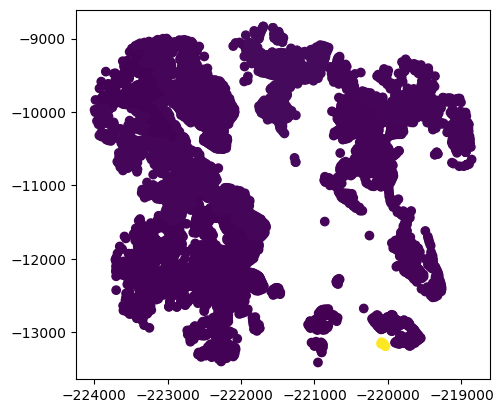

In [51]:
pge_buildings_linked.plot(column = 'INDIVIDUAL_HOMES_HOST_CAP_WOF_KW')

## Repeat workflow for generation capacity *with* operational flex

Starting with Step 4 --> the first place generation capacity is introduced.

In [52]:
# replicate entire pipeline from above

# Step 4
# find maximum generation across feederline
max_gen = alameda_singlefamily_linked.groupby('circuit_id').max('GenCapac_1')

# save just the necessary column and rename
max_gen_feeder = max_gen['GenCapac_1'].rename('max_gen_opflex')

# join max generation by feeder to entire df
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    max_gen_feeder,
    on = 'circuit_id')

# Step 10b
circ_poly_gen = alameda_singlefamily_linked.groupby(['GEOID_right', 'circuit_id']).max('GenCapac_1')

circ_poly_gen_max = circ_poly['GenCapac_1'].rename('DER_max_Cpoly_opflex')

alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    circ_poly_gen_max,
    on = ['GEOID_right', 'circuit_id'])

# Step 11
# calculate weight by household
alameda_singlefamily_linked['_hhWt_opflex'] = alameda_singlefamily_linked['DER_max_Cpoly_opflex'] * (alameda_singlefamily_linked['tothh_Cpoly'] / alameda_singlefamily_linked['home_count_circuit'])

# Step 12
# calculate summation of household-weighted max capacity across circuit
summ_hhWt = alameda_singlefamily_linked.groupby('circuit_id').sum('_hhWt_opflex')

# save the summed column and rename
summ_hhWt = summ_hhWt['_hhWt_opflex'].rename('summ_hhWt_opflex')

# add to data frame through join
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    summ_hhWt,
    on = ['circuit_id'])

# equation 9
alameda_singlefamily_linked['_hhWt_n_opflex'] = alameda_singlefamily_linked['_hhWt_opflex'] * (alameda_singlefamily_linked['max_gen_opflex'] / alameda_singlefamily_linked['summ_hhWt_opflex'])

# Step 13
alameda_singlefamily_linked['_hhWt_n_opflex'] = np.where(
    
    # condition -- weighted generation is greater than max generation across circuit/feederline
    alameda_singlefamily_linked['_hhWt_n_opflex'] > alameda_singlefamily_linked['DER_max_Cpoly_opflex'],
    
    # replace with max generation of feederline if condition is true
    alameda_singlefamily_linked['DER_max_Cpoly_opflex'], 
    
    # otherwise, keep original calculated value
    alameda_singlefamily_linked['_hhWt_n_opflex'])

# Step 14
alameda_singlefamily_linked['DER_remain_opflex'] = alameda_singlefamily_linked['_hhWt_n_opflex'] / alameda_singlefamily_linked['tothh_Cpoly'] * 1000

NameError: name 'alameda_singlefamily_linked' is not defined

#### Explore

In [ ]:
alameda_singlefamily_linked['DER_remain_opflex'].describe()

In [ ]:
alameda_singlefamily_linked['DER_remain'].describe()

**With** operational flex appears to have larger generation capacity values, and no negative ones (opposite of the raw exploration we did before...does this make sense?)

In [ ]:
alameda_singlefamily_linked['DER_remain_opflex'].plot(kind = "hist")

minor change

In [ ]:
# create length column in metres
sdge_feederlines['LENGTH(M)'] = sdge_feederlines.length

#### Step 2: Add census tract ID (TRACTCE) to each home through spatial join

These tract IDs should be added to the homes dataframes as they are necessary for further calculations. 


In [ ]:
# make sure the dataframes have the same crs before performing spatial computations
assert census_tracts.crs == sdge_multifamily_linked.crs
assert census_tracts.crs == sdge_singlefamily_linked.crs

# assign each home to its census tracts
sdge_singlefamily_linked = gpd.sjoin(sdge_singlefamily_linked, census_tracts[['TRACTCE', 'geometry']], how = "left", predicate = "within")
sdge_multifamily_linked = gpd.sjoin(sdge_multifamily_linked, census_tracts[['TRACTCE', 'geometry']], how = "left", predicate = "within")

#### Step 3: Calculate the number of homes in each census tract

The number of homes in each census tract is used further in the calculation. Save it as a new column in the homes dataframes. 

In [ ]:
sdge_singlefamily_linked['TOTAL_HOMES_PER_TRACT'] = sdge_singlefamily_linked.groupby('TRACTCE')['TRACTCE'].transform('count')
sdge_multifamily_linked['TOTAL_HOMES_PER_TRACT'] = sdge_multifamily_linked.groupby('TRACTCE')['TRACTCE'].transform('count')

#### Step 4: Calculate the maximum ICA generation capacity for each circuit

Generation capacity varies across the circuit. The maximum is utilized in calculating the hosting capacity. Add the new data to the data frame as a column.


In [ ]:
# save the max ICA generation capacity by the circuit
sdge_singlefamily_linked['MAX_GEN_WOF_CIRCUIT'] = sdge_singlefamily_linked.groupby('CIRCUIT_NAME')['ICAWOF_UNIGENERATION'].transform('max')
sdge_singlefamily_linked['MAX_GEN_WNOF_CIRCUIT'] = sdge_singlefamily_linked.groupby('CIRCUIT_NAME')['ICAWNOF_UNIGENERATION'].transform('max')

sdge_multifamily_linked['MAX_GEN_WOF_CIRCUIT'] = sdge_multifamily_linked.groupby('CIRCUIT_NAME')['ICAWOF_UNIGENERATION'].transform('max')
sdge_multifamily_linked['MAX_GEN_WNOF_CIRCUIT'] = sdge_multifamily_linked.groupby('CIRCUIT_NAME')['ICAWNOF_UNIGENERATION'].transform('max')

#### Step 5: Calculate the percentage of the length of each segment relative to the entire feederline

First calculate the length of the whole circuit. Then divide each segment’s length by the length of the whole circuit. Save to the dataframe in a new column. 


In [ ]:
# calculate the whole length of the circuit
sdge_circuit_lengths = sdge_feederlines.groupby('CIRCUIT_NAME').sum('LENGTH(M)')

# rename the column that has the total length
sdge_circuit_lengths.rename(columns = {'LENGTH(M)':'TOTAL_CIRCUIT_LENGTH(M)'}, inplace = True)

# join the circuit lengths to the original dataframe
sdge_feederlines_lengths = pd.merge(sdge_feederlines, sdge_circuit_lengths['TOTAL_CIRCUIT_LENGTH(M)'], on = 'CIRCUIT_NAME', how = 'left')

# calculate the percentage of the length of each segment relative to the whole dataframe
sdge_feederlines_lengths['PERCENT_LENGTH_OF_CIRCUIT'] = sdge_feederlines_lengths['LENGTH(M)']/sdge_feederlines_lengths['TOTAL_CIRCUIT_LENGTH(M)']

sdge_feederlines_lengths.head()

#### Step 6:  Calculate the number of homes connected to each segment



In [ ]:
# aggregate number of homes that connect to each segment
sdge_singlefamily_linked ['TOTAL_HOMES_PER_SEGMENT'] = sdge_singlefamily_linked.groupby('LINE_SEGMENT_NUMBER')['LINE_SEGMENT_NUMBER'].transform('count')
sdge_multifamily_linked ['TOTAL_HOMES_PER_SEGMENT'] = sdge_multifamily_linked.groupby('LINE_SEGMENT_NUMBER')['LINE_SEGMENT_NUMBER'].transform('count')

#### Step 7:  Calculate the total number of homes connected to the whole circuit

In [ ]:
# aggregate number of homes that connect to each circuit
sdge_singlefamily_linked ['TOTAL_HOMES_PER_CIRCUIT'] = sdge_singlefamily_linked.groupby('CIRCUIT_NAME')['CIRCUIT_NAME'].transform('count')
sdge_multifamily_linked ['TOTAL_HOMES_PER_CIRCUIT'] = sdge_multifamily_linked.groupby('CIRCUIT_NAME')['CIRCUIT_NAME'].transform('count')

#### Step 8:  Calculate the percent of homes connected to each segment relative to all of the homes connected to the entire circuit

In [ ]:
sdge_singlefamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT'] = sdge_singlefamily_linked['TOTAL_HOMES_PER_SEGMENT'] / sdge_singlefamily_linked['TOTAL_HOMES_PER_CIRCUIT']
sdge_multifamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT'] = sdge_multifamily_linked['TOTAL_HOMES_PER_SEGMENT'] / sdge_multifamily_linked['TOTAL_HOMES_PER_CIRCUIT']

#### Step 9:  Calculate the weighted generation capacity for each segment of the feederline

Multiply the total generation capacity of the segment by the percent of homes connected to each segment. This calculation undercounts the total generation capacity.

In [ ]:
# weighted generation capacity calculations single family homes
sdge_singlefamily_linked['WEIGHTED_GEN_CAPWOF'] = sdge_singlefamily_linked['ICAWOF_UNIGENERATION'] * sdge_singlefamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']
sdge_singlefamily_linked['WEIGHTED_GEN_CAPWNOF'] = sdge_singlefamily_linked['ICAWNOF_UNIGENERATION'] * sdge_singlefamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']

# weighted generation capacity calculations multi family homes
sdge_multifamily_linked['WEIGHTED_GEN_CAPWOF'] = sdge_multifamily_linked['ICAWOF_UNIGENERATION'] * sdge_multifamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']
sdge_multifamily_linked['WEIGHTED_GEN_CAPWNOF'] = sdge_multifamily_linked['ICAWNOF_UNIGENERATION'] * sdge_multifamily_linked['PERC_HOMES_PER_SEGMENT_COMP_CIRCUIT']

#### Step 10:  Calculate the number of homes located within each census tract for each circuit


In [ ]:
sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT'] = sdge_singlefamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['CIRCUIT_NAME'].transform('count')
sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT'] = sdge_multifamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['CIRCUIT_NAME'].transform('count')

#### Step 11:  Calculate the weighted household max hosting capacity for each circuit tract combo

Divide the number of homes located within each census tract for each circuit by the total number of homes connected to the whole circuit and multiply that value by the max generation capacity report for each circuit tract combo.


In [ ]:
# calculate the max generation capacity for the circuit tract combo
sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'] = sdge_singlefamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWOF_UNIGENERATION'].transform('max')
sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'] = sdge_singlefamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWNOF_UNIGENERATION'].transform('max')

sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'] = sdge_multifamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWOF_UNIGENERATION'].transform('max')
sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'] = sdge_multifamily_linked.groupby(['CIRCUIT_NAME', 'TRACTCE'])['ICAWNOF_UNIGENERATION'].transform('max')


In [ ]:
# calculate the weighted household max hosting capacity for each circuit tract combo
sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT'] = (sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_singlefamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT']
sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT'] = (sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_singlefamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT']

sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT'] = (sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_multifamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT']
sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT'] = (sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']/ sdge_multifamily_linked['TOTAL_HOMES_PER_CIRCUIT']) * sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT']

####  Step 12:  Normalize the generation capacity for each circuit polygon combo

We normalize the generation capacity because weighting the generation capacity under counts the total number of MW available. 

Divide the maximum hosting capacity from anywhere on the given circuit by the  weighted household max hosting capacity for each circuit tract combo, and then multiply by the  weighted household max hosting capacity for each circuit tract combo. 



In [ ]:
sdge_singlefamily_linked['NORMALIZED_GEN_WOF'] = (sdge_singlefamily_linked['MAX_GEN_WOF_CIRCUIT'] / sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']) * sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']
sdge_singlefamily_linked['NORMALIZED_GEN_WNOF'] = (sdge_singlefamily_linked['MAX_GEN_WNOF_CIRCUIT'] / sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']) * sdge_singlefamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']

sdge_multifamily_linked['NORMALIZED_GEN_WOF'] = (sdge_multifamily_linked['MAX_GEN_WOF_CIRCUIT'] / sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']) * sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WOF_CIRCUIT_TRACT']
sdge_multifamily_linked['NORMALIZED_GEN_WNOF'] = (sdge_multifamily_linked['MAX_GEN_WNOF_CIRCUIT'] / sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']) * sdge_multifamily_linked['WEIGHTED_MAX_HOST_CAP_WNOF_CIRCUIT_TRACT']

#### Step 13:  Adjust the normalized values to the maximum generation

For each normalized value for the circuit polygon combos, ensure they are not over the original maximum value for that circuit polygon. Adjust down to the max where necessary.


In [ ]:
sdge_singlefamily_linked['ADJUSTED_NORM_GEN_WOF'] = np.where(sdge_singlefamily_linked['NORMALIZED_GEN_WOF'] > sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['NORMALIZED_GEN_WOF'])
sdge_singlefamily_linked['ADJUSTED_NORM_GEN_WNOF'] = np.where(sdge_singlefamily_linked['NORMALIZED_GEN_WNOF'] > sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_singlefamily_linked['NORMALIZED_GEN_WNOF'])

sdge_multifamily_linked['ADJUSTED_NORM_GEN_WOF'] = np.where(sdge_multifamily_linked['NORMALIZED_GEN_WOF'] > sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['MAX_GEN_WOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['NORMALIZED_GEN_WOF'])
sdge_multifamily_linked['ADJUSTED_NORM_GEN_WNOF'] = np.where(sdge_multifamily_linked['NORMALIZED_GEN_WNOF'] > sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['MAX_GEN_WNOF_BY_CIRCUIT_TRACT'], sdge_multifamily_linked['NORMALIZED_GEN_WNOF'])

#### Step 14: Calculate the household hosting capacity

Divide the generation capacity for the circuit tracts by the number of homes connected in that circuit tract.

In [ ]:
sdge_singlefamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'] = (sdge_singlefamily_linked['ADJUSTED_NORM_GEN_WOF'] / sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']) * 1000
sdge_singlefamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WNOF_KW'] = (sdge_singlefamily_linked['ADJUSTED_NORM_GEN_WNOF'] / sdge_singlefamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']) * 1000

sdge_multifamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'] = (sdge_multifamily_linked['ADJUSTED_NORM_GEN_WOF'] / sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']) * 1000
sdge_multifamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WNOF_KW'] = (sdge_multifamily_linked['ADJUSTED_NORM_GEN_WNOF'] / sdge_multifamily_linked['HOMES_COUNT_BY_TRACT_CIRCUIT']) * 1000

### Explore the hosting capacity results

In [ ]:
sdge_singlefamily_linked.head()

In [ ]:
sdge_multifamily_linked.head()

In [ ]:
sdge_singlefamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'].describe()

In [ ]:
sdge_singlefamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WNOF_KW'].describe()

In [ ]:
sdge_multifamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'].describe()

In [ ]:
sdge_singlefamily_linked[sdge_singlefamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WOF_KW'] < 0]

In [ ]:
sdge_singlefamily_linked[sdge_singlefamily_linked['INDIVIDUAL_HOMES_HOST_CAP_WNOF_KW'] < 0]

# Map all of the data sources

In [ ]:
# plot all of the data sources to ensure everything looks accurate 
fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

sdge_singlefamily_linked.plot(ax=ax, 
                    color='black')

sdge_multifamily_linked.plot(ax=ax, 
                    color='#F6BE9A')

sdge_feederlines.plot(ax=ax, 
                      color='#004643')

census_tracts.boundary.plot(ax=ax, 
                    color='red')

In [ ]:
# verify all of the data frames have the same crs 
assert census_tracts.crs == sdge_feederlines.crs
assert census_tracts.crs == sdge_multifamily_linked.crs
assert census_tracts.crs == sdge_singlefamily_linked.crs

# filter census tract to just one census tract
example_census = census_tracts[census_tracts['TRACTCE'] == '004200']

# clip all of the other data to the one census tract
example_feeder = sdge_feederlines.clip(example_census)
example_multifamily = sdge_multifamily_linked.clip(example_census)
example_singlefamily = sdge_singlefamily_linked.clip(example_census)


Let's make sure this is a good census tract to conduct a hosting capacity analysis on. Let's count the number of homes in this census tract.

In [ ]:
print(f"The selected census tract has",len(example_singlefamily), " single family homes.")

In [ ]:
# plot all of the data sources to ensure just one census tract is present 
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

example_singlefamily.plot(ax=ax, 
                    color='black')

example_multifamily.plot(ax=ax, 
                    color='#F6BE9A')

example_feeder.plot(ax=ax, 
                      color='#004643')

example_census.boundary.plot(ax=ax, 
                    color='red')

plt.title('Example census tract')

#### 1. View the maximum hosting capactiy
For this example let's look at the ICA with no operational flex uniform generation.

In [ ]:
# view the max ICA no operational flex 
print(example_singlefamily['ICAWNOF_UNIGENERATION'].max())
print(example_multifamily['ICAWNOF_UNIGENERATION'].max())
print(example_feeder['ICAWNOF_UNIGENERATION'].max())

The maximum ICA with no operational flex uniform generation are the same across the feederlines, the single family homes, and the multi-family homes. This is expected since the feederlines are connected to all of the residential buildings. 

In [ ]:
# view the minimum ICA with no operational flex generation capacity 
print(example_singlefamily['ICAWNOF_UNIGENERATION'].min())
print(example_multifamily['ICAWNOF_UNIGENERATION'].min())
print(example_feeder['ICAWNOF_UNIGENERATION'].min())

# Calculate hosting capacity for only one census/polygon combo as an example
The hosting capacity calculation is complex. To ensure we understand the step by step process we'll work on just one circuit polygon combo. Then we can create a for loop to iterate the analysis over all of the census tracts and feederlines.


#### Step 1: Link the homes to the nearest feederline

Each home gets its electricty from a specific feederline. The nearest neighbor is the method chosen. Then to avoid including homes that are outliers and likely gettin electricity from other sources homes that are further than 1km from their assigned feederline are dropped. 